In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

In [7]:
# =========================
# Load Dataset
# =========================
data_path = "Tweets.csv"
df = pd.read_csv(data_path)

X = df["text"].astype(str)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# =========================
# TF-IDF Vectorization
# =========================
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [9]:
# =========================
# SVM + GridSearch
# =========================
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm = SVC(
    probability=True,
    class_weight="balanced"
)

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train_tfidf, y_train)

best_svm = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [10]:
# =========================
# Evaluation
# =========================
y_pred = best_svm.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")
f1 = f1_score(y_test, y_pred, average="binary")

print("\nModel Performance Metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Model Performance Metrics
Accuracy : 0.8572
Precision: 0.8821
Recall   : 0.9166
F1-score : 0.8990


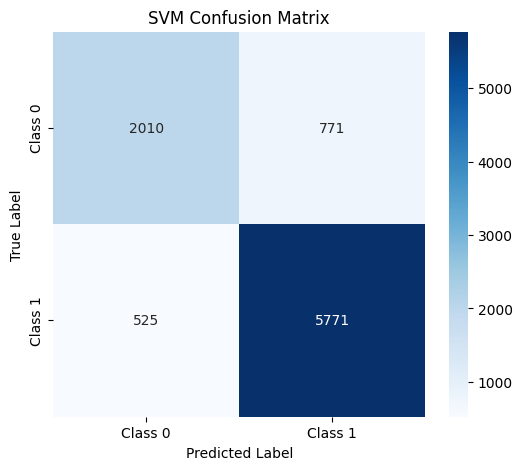

In [11]:
# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [12]:
# =========================
# Save Model & Vectorizer
# =========================
dump(best_svm, "SVM_model.joblib")
dump(vectorizer, "TFidf_vector.joblib")

print("\nModel saved as: SVM_model.joblib")
print("\nVectorizer saved as: TFidf_vector.joblib")


Model saved as: SVM_model.joblib

Vectorizer saved as: TFidf_vector.joblib


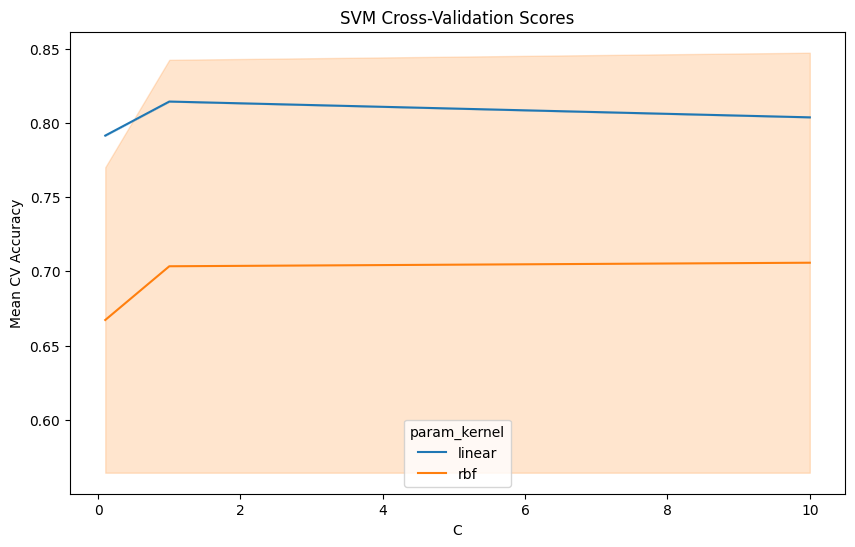

In [15]:
import pandas as pd

# Create a DataFrame from cv_results_
cv_results = pd.DataFrame(grid_search.cv_results_)

# Plot mean test scores for each parameter combination
plt.figure(figsize=(10, 6))
sns.lineplot(data=cv_results, x='param_C', y='mean_test_score', hue='param_kernel')
plt.title('SVM Cross-Validation Scores')
plt.xlabel('C')
plt.ylabel('Mean CV Accuracy')
# plt.savefig('../models/svm_cv_results.png')
plt.show()


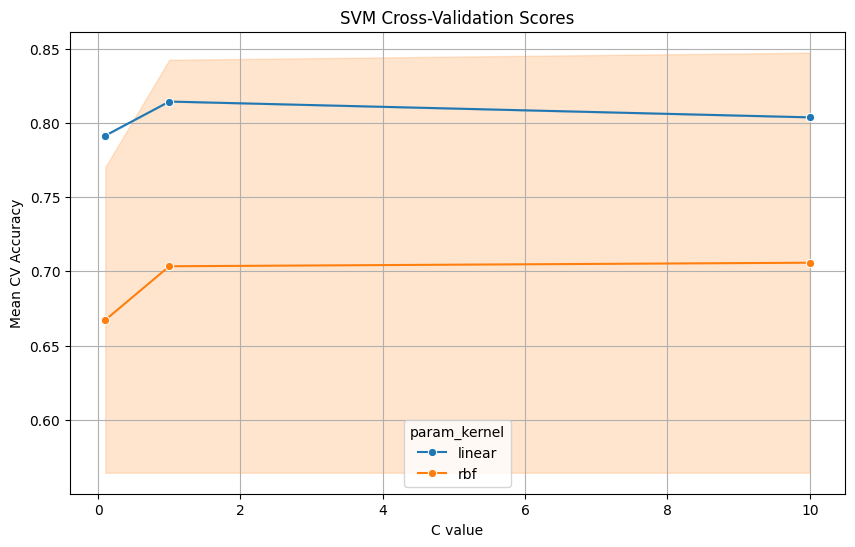

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cv_results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 6))
sns.lineplot(data=cv_results, x='param_C', y='mean_test_score', hue='param_kernel', marker='o')
plt.title('SVM Cross-Validation Scores')
plt.xlabel('C value')
plt.ylabel('Mean CV Accuracy')
plt.grid(True)
# plt.savefig('../models/svm_cv_results.png')
plt.show()
